# Diabetes Health Indicators
# Mini-Lab: Logistic Regression and Support Vector Machines

## BRFSS 2015 Diabetes Health Indicators Dataset

**Author:** Nashita Khandaker
**Course:** Intro to AI
**Date:** September 2026

# 1. Introduction

## 1.1 The Classification Task

In Lab 1 we explored the BRFSS 2015 diabetes health indicators data (253,680
respondents, 21 features). In this mini-lab we do the Modeling and Evaluation
steps of CRISP-DM. We fit a logistic regression and a support vector machine to
the same task, tune both, compare them, and look at what each model tells us
about the data.

We use the same target as Lab 1, `Diabetes_binary`. It is 1 if the respondent
says a doctor told them they have prediabetes or diabetes, and 0 otherwise.
15.76% of respondents are in the positive class.

As in Lab 1, the target is a *diagnosis*, not the disease itself. Someone who has
diabetes but was never tested is counted as a 0. So the models learn who has been
diagnosed, and this limits how accurate any of them can be.

## 1.2 How the Models Are Judged

The data is imbalanced. Predicting "no diabetes" for everyone already gets 84%
accuracy, so we report accuracy but don't use it to pick models.

| Metric | What it measures | How we use it |
|---|---|---|
| ROC-AUC | How well the model ranks diabetics above non-diabetics, over all thresholds (0.5 = guessing, 1 = perfect) | Main metric. Used for all hyperparameter searches. |
| Recall | Share of diagnosed diabetics the model flags | Missing a case is the worst error here. |
| Precision | Share of flagged people who are actually diagnosed | Shows how many false alarms there are. |
| F1 | Harmonic mean of precision and recall | Used to pick the decision threshold. |
| Fit time | Seconds to train the model once | Used for the efficiency question in Section 5. |

ROC-AUC only depends on how the model ranks people. That means we can use it for
both the logistic regression (which outputs a probability) and the SVM (which
outputs a decision value, not a probability).

## 1.3 Assumptions and Decisions Carried Over from Lab 1

1. Binary target: prediabetes (1.8% of rows) is combined with diabetes, as in Lab 1.
2. We drop the healthcare-access variables `CholCheck`, `AnyHealthcare` and
   `NoDocbcCost`. Lab 1 (Section 15.2) showed they measure who gets *diagnosed*
   more than who is sick. That leaves 18 features.
3. We keep duplicate rows. Lab 1 showed that removing them would artificially
   raise the prevalence. Identical rows are real people who happened to give the
   same answers to 18 fairly coarse questions.
4. We use raw BMI. A few extreme values don't have much effect on a linear model
   with standardized features, and the raw column is easier to interpret (odds
   per BMI point).
5. Ordinal features are treated as numbers. `Age` (13 bands), `GenHlth` (1-5),
   `Education` (1-6) and `Income` (1-8) are each one numeric column. This assumes
   each step up the scale has the same effect on the log-odds. That is a
   simplification, since Lab 1 found the age curve bends down in the oldest bands.
6. All features are standardized inside a pipeline, so the scaler only learns
   means and standard deviations from the training rows. SVMs need this, and it
   also lets us compare the logistic weights across features.
7. Every tuned model uses `class_weight="balanced"`. During training, a missed
   diabetic counts about 5.3 times as much as a false alarm.
8. We use an 80/20 stratified split with seed 42. All tuning is done with
   cross-validation inside the 80%. The 20% test set is only used for the final
   numbers.

# 2. Setup and Data Preparation

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")
os.environ["PYTHONWARNINGS"] = "ignore"   # silence the parallel worker processes too

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     StratifiedKFold, cross_val_predict)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import (accuracy_score, recall_score, precision_score, f1_score,
                             roc_auc_score, roc_curve, precision_recall_curve)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", "{:.3f}".format)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.titleweight"] = "600"

# Same palette as Lab 1, so a colour means the same thing in both reports
PALETTE = {
    "ink":    "#22303c",
    "grid":   "#dfe4e8",
    "neg":    "#8fa3b0",   # reference / unexposed
    "pos":    "#b5442e",   # diabetes / elevated
    "prot":   "#2f6f6a",   # protective direction
    "accent": "#c98a1b",
}
SEQ = sns.blend_palette(["#f5f2ea", "#d8b26a", PALETTE["pos"], "#5c1d13"], as_cmap=True)

SEED = 42
CV5  = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
raw = pd.read_csv("../data/diabetes_012_health_indicators_BRFSS2015.csv")

# Decision #1 (Lab 1): collapse prediabetes and diabetes into one positive class
raw["Diabetes_binary"] = (raw["Diabetes_012"] >= 1).astype(int)
TARGET = "Diabetes_binary"

# Decision #7 (Lab 1): withhold the healthcare-access variables, which measure
# who gets diagnosed rather than who is sick
ACCESS   = ["CholCheck", "AnyHealthcare", "NoDocbcCost"]
FEATURES = [c for c in raw.columns if c not in ["Diabetes_012", TARGET] + ACCESS]

X = raw[FEATURES].astype(float)
y = raw[TARGET]

print(f"rows       : {len(raw):,}")
print(f"features   : {len(FEATURES)}  (dropped {', '.join(ACCESS)})")
print(f"prevalence : {100*y.mean():.2f}%")

rows       : 253,680
features   : 18  (dropped CholCheck, AnyHealthcare, NoDocbcCost)
prevalence : 15.76%


The split is stratified, so both sides have the same 15.8% prevalence. We only
split once. Every model below is trained on the same 202,944 training rows (or a
sample of them) and tested on the same 50,736 test rows.

In [3]:
# 80/20 split as the assignment requires, stratified so both sides carry the same
# class balance. The test set is not touched again until models are compared.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)

print(f"Training rows : {len(X_train):,}   positive rate {y_train.mean():.3f}")
print(f"Test rows     : {len(X_test):,}    positive rate {y_test.mean():.3f}")

Training rows : 202,944   positive rate 0.158
Test rows     : 50,736    positive rate 0.158


In [4]:
results = []

def evaluate(name, score, pred, fit_seconds=np.nan):
    """Test-set metrics. `score` is a probability or an SVM decision value:
    ROC-AUC only needs a ranking, so either works."""
    row = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, score),
        "Fit time (s)": fit_seconds,
    }
    results.append(row)
    return row

def timed_fit(model, X_, y_):
    t0 = time.perf_counter()
    model.fit(X_, y_)
    return model, time.perf_counter() - t0

def f1_threshold(y_true, score):
    """Cut-off on `score` that maximises F1."""
    p, r, t = precision_recall_curve(y_true, score)
    f1 = 2 * p * r / np.clip(p + r, 1e-12, None)
    return t[np.argmax(f1[:-1])]

def show_results(names=None):
    df = pd.DataFrame(results).drop_duplicates("Model", keep="last").set_index("Model")
    return (df if names is None else df.loc[names]).round(3)

# 3. Logistic Regression

## 3.1 Baseline

We start with three baselines: a model that predicts nobody has diabetes,
logistic regression with scikit-learn's default settings, and the same model
with balanced class weights (our preliminary model from Lab 1).

In [5]:
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
evaluate("Predict nobody has diabetes",
         dummy.predict_proba(X_test)[:, 1], dummy.predict(X_test))

def logit_pipe(**kw):
    return Pipeline([("scale", StandardScaler()),
                     ("clf", LogisticRegression(max_iter=2000, random_state=SEED, **kw))])

lr_default, t = timed_fit(logit_pipe(), X_train, y_train)
p = lr_default.predict_proba(X_test)[:, 1]
evaluate("Logistic, default", p, (p >= 0.5).astype(int), t)

lr_weighted, t = timed_fit(logit_pipe(class_weight="balanced"), X_train, y_train)
p = lr_weighted.predict_proba(X_test)[:, 1]
evaluate("Logistic, class-weighted", p, (p >= 0.5).astype(int), t)

show_results()

,Accuracy,Recall,Precision,F1,ROC-AUC,Fit time (s)
Model,,,,,,
Predict nobody has diabetes,0.842,0.000,0.000,0.000,0.500,NaN
"Logistic, default",0.848,0.189,0.552,0.281,0.816,0.249
"Logistic, class-weighted",0.730,0.759,0.341,0.470,0.816,0.288


### Interpretation

The default logistic regression is less than one point more accurate than the
do-nothing baseline (84.8% vs 84.2%), and it only finds 19% of the diabetics.
With a 0.50 cut-off and only 16% positives, it almost never predicts diabetes.

Class weighting raises recall from 19% to 76%, but accuracy drops by 12 points.
ROC-AUC stays at 0.816 for both. So weighting doesn't make the model better at
ranking people. It just changes which kind of mistake the model makes more
often. We come back to this difference between ranking and the chosen cut-off
throughout the report.

## 3.2 Tuning the Regularization

The main hyperparameters of logistic regression are the regularization
strength `C` (a smaller `C` shrinks the weights more toward zero) and the type of
penalty. L2 shrinks all the weights a little, and L1 can set some weights to
exactly zero. We try both penalties with seven values of `C`, using 5-fold
cross-validation scored on ROC-AUC.

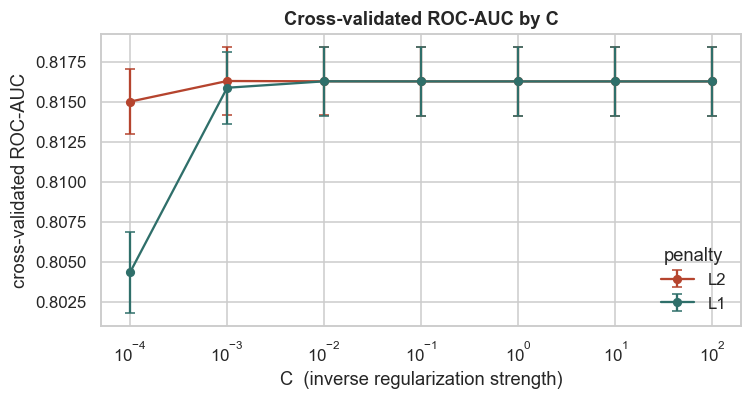

best parameters : {'clf__C': np.float64(0.001), 'clf__l1_ratio': 0}
best CV ROC-AUC : 0.8163
spread across C >= 0.01 : [0.8163, 0.8163]
grid search time: 26s for 70 fits


In [6]:
lr_grid = GridSearchCV(
    Pipeline([("scale", StandardScaler()),
              ("clf", LogisticRegression(solver="liblinear", class_weight="balanced",
                                         max_iter=2000, random_state=SEED))]),
    # l1_ratio=1 is the L1 (lasso) penalty, l1_ratio=0 is L2 (ridge)
    param_grid={"clf__C": np.logspace(-4, 2, 7), "clf__l1_ratio": [0, 1]},
    scoring="roc_auc", cv=CV5, n_jobs=-1)

t0 = time.perf_counter()
lr_grid.fit(X_train, y_train)
lr_search_time = time.perf_counter() - t0

cv_lr = pd.DataFrame(lr_grid.cv_results_)
cv_lr = cv_lr.assign(C=cv_lr.param_clf__C.astype(float),
                     penalty=np.where(cv_lr.param_clf__l1_ratio.astype(float) == 1, "l1", "l2"))

fig, ax = plt.subplots(figsize=(7, 3.8))
for pen, color in [("l2", PALETTE["pos"]), ("l1", PALETTE["prot"])]:
    d = cv_lr[cv_lr.penalty == pen].sort_values("C")
    ax.errorbar(d.C, d.mean_test_score, yerr=d.std_test_score, fmt="-o", ms=5,
                capsize=3, color=color, label=pen.upper())
ax.set_xscale("log")
ax.set_xlabel("C  (inverse regularization strength)")
ax.set_ylabel("cross-validated ROC-AUC")
ax.set_title("Cross-validated ROC-AUC by C")
ax.legend(title="penalty", frameon=False)
plt.tight_layout(); plt.show()

print(f"best parameters : {lr_grid.best_params_}")
print(f"best CV ROC-AUC : {lr_grid.best_score_:.4f}")
print(f"spread across C >= 0.01 : "
      f"{cv_lr[cv_lr.C >= 0.01].mean_test_score.agg(['min', 'max']).round(4).tolist()}")
print(f"grid search time: {lr_search_time:.0f}s for {len(cv_lr) * 5} fits")

### Interpretation

Regularization barely matters here. With L2, the cross-validated ROC-AUC is
0.816 for every `C` from 0.001 to 100. Only very strong regularization hurts: at
`C = 0.0001`, L1 drops to 0.804 because it starts removing useful features. The
grid search picks `C = 0.001` with L2, but it only beats the default `C = 1` in
the fourth decimal, which is smaller than the variation between folds.

This makes sense with 203k rows and 18 features. That is about 11,000 rows per
parameter, so the model can't really overfit, and regularization has nothing to
fix. The model is limited by bias instead: the features are simple, mostly
yes/no survey answers, and the target is a diagnosis rather than a measurement.
Tuning can't change either of those.

## 3.3 Choosing the Decision Threshold

Since tuning `C` doesn't improve the ranking, the other thing we can change is
the decision threshold. We pick the threshold that gives the best F1 on
*out-of-fold* predictions from the training set. This way the test set isn't
used to choose it.

In [7]:
lr_best = lr_grid.best_estimator_
_, lr_fit_time = timed_fit(lr_best, X_train, y_train)

# Out-of-fold probabilities on the training set pick the threshold, so the test
# set plays no part in the choice
oof_lr = cross_val_predict(lr_best, X_train, y_train, cv=CV5,
                           method="predict_proba", n_jobs=-1)[:, 1]
lr_thr = f1_threshold(y_train, oof_lr)

p_lr = lr_best.predict_proba(X_test)[:, 1]
evaluate("Logistic, tuned (0.50)", p_lr, (p_lr >= 0.5).astype(int), lr_fit_time)
evaluate("Logistic, tuned (F1 threshold)", p_lr, (p_lr >= lr_thr).astype(int), lr_fit_time)

print(f"F1-optimal threshold from out-of-fold training predictions: {lr_thr:.3f}")
show_results()

F1-optimal threshold from out-of-fold training predictions: 0.592


,Accuracy,Recall,Precision,F1,ROC-AUC,Fit time (s)
Model,,,,,,
Predict nobody has diabetes,0.842,0.000,0.000,0.000,0.500,NaN
"Logistic, default",0.848,0.189,0.552,0.281,0.816,0.249
"Logistic, class-weighted",0.730,0.759,0.341,0.470,0.816,0.288
"Logistic, tuned (0.50)",0.728,0.762,0.339,0.469,0.816,0.604
"Logistic, tuned (F1 threshold)",0.779,0.653,0.382,0.482,0.816,0.604


### Interpretation

Raising the threshold from 0.50 to 0.59 lowers recall (76% to 65%) and raises
precision (34% to 38%). Accuracy goes up from 72.8% to 77.9% and F1 from 0.469
to 0.482. ROC-AUC stays the same because the ranking doesn't change.

Neither threshold is the "right" one. The 0.50 threshold with class weights fits
a screening program where missing a case is expensive. The F1 threshold fits a
program where false alarms also cost a lot, for example one with a limited budget
for follow-up tests. We report both for every model below so the comparison is
fair.

# 4. Support Vector Machines

## 4.1 Choosing a Kernel

An SVM finds the boundary between the classes with the widest possible margin.
The kernel controls the shape of that boundary. A linear kernel gives a flat
boundary (a hyperplane), like logistic regression. An RBF (radial basis
function) kernel lets the boundary curve around groups of points.

The assignment says that if the dataset is too large for a kernel SVM, a linear
kernel is fine. Before deciding, we checked this by timing scikit-learn's `SVC`
(the general kernel SVM solver, libsvm) on bigger and bigger samples of the
training set.

In [8]:
# Fit kernel SVMs on growing stratified subsamples and time them
sizes, timing = [2_500, 5_000, 10_000, 20_000], []
for n in sizes:
    Xs, _, ys, _ = train_test_split(X_train, y_train, train_size=n,
                                    random_state=SEED, stratify=y_train)
    for kernel in ["linear", "rbf"]:
        m = Pipeline([("scale", StandardScaler()),
                      ("clf", SVC(kernel=kernel, C=1.0, class_weight="balanced"))])
        _, t = timed_fit(m, Xs, ys)
        timing.append({"n": n, "kernel": kernel, "seconds": t,
                       "support vectors": m[-1].n_support_.sum()})
timing = pd.DataFrame(timing)
display(timing.pivot(index="n", columns="kernel", values=["seconds", "support vectors"]).round(1))

# Rough estimate for the full training set: if time grows with the square of the
# rows, going from 20,000 rows to all of them multiplies the time by (n_full / 20,000)^2
n_full = len(X_train)
t20k = timing[timing.n == 20_000].set_index("kernel")["seconds"]
extrap = t20k * (n_full / 20_000) ** 2
for kernel, secs in extrap.items():
    print(f"{kernel:6s}: {t20k[kernel]:.0f}s at 20,000 rows  ->  roughly {secs/3600:.1f} hours "
          f"at {n_full:,} rows (one fit, one setting of C)")

seconds        support vectors          
kernel  linear    rbf          linear       rbf
n                                              
2500     0.300  0.300        1574.000  1568.000
5000     1.400  1.200        3021.000  2956.000
10000    6.100  5.300        6037.000  5820.000
20000   22.600 21.900       12020.000 11501.000

linear: 23s at 20,000 rows  ->  roughly 0.6 hours at 202,944 rows (one fit, one setting of C)
rbf   : 22s at 20,000 rows  ->  roughly 0.6 hours at 202,944 rows (one fit, one setting of C)


### Interpretation

`SVC` fit time grows roughly with the square of the number of rows, for both
kernels. Going from 10,000 to 20,000 rows makes it about four times slower
(about 6 seconds to about 25). For all 202,944 training rows, a single fit with
a single value of `C` would take most of an hour. A 5-fold grid search over a
dozen settings would take more than a day. Predicting is slow too, because an RBF
model compares each new row with every support vector, and more than half of the
training rows end up as support vectors (right-hand column).

The slow part is the libsvm solver, not the kernel. `LinearSVC` uses a solver
made for the linear case, which doesn't need to compare every row with every
other row. So our plan is:

1. Linear kernel on the full training set (Section 4.2). This is our main SVM,
   and the one we compare with logistic regression.
2. RBF kernel on a 10,000-row sample (Section 4.3), to see if a curved boundary
   finds anything a straight one misses. Based on Lab 1 we don't expect much,
   because age and BMI add up almost linearly on the log-odds scale (Lab 1,
   Section 7.6), which is what a linear model can already capture.

## 4.2 Linear SVM on the Full Training Set

We tune `LinearSVC` over `C` (a larger `C` means a narrower margin that allows
fewer points inside it). Like the logistic regression, it uses balanced class
weights and 5-fold cross-validation on ROC-AUC.

In [9]:
svm_grid = GridSearchCV(
    Pipeline([("scale", StandardScaler()),
              ("clf", LinearSVC(dual=False, class_weight="balanced", random_state=SEED))]),
    param_grid={"clf__C": np.logspace(-4, 1, 6)},
    scoring="roc_auc", cv=CV5, n_jobs=-1)
svm_grid.fit(X_train, y_train)

display(pd.DataFrame({
    "C (LinearSVC)": svm_grid.cv_results_["param_clf__C"].astype(float),
    "CV ROC-AUC": svm_grid.cv_results_["mean_test_score"]}).round(4).T)
print(f"LinearSVC best : {svm_grid.best_params_}  CV ROC-AUC {svm_grid.best_score_:.4f}")

,0,1,2,3,4,5
C (LinearSVC),0.000,0.001,0.010,0.100,1.000,10.000
CV ROC-AUC,0.816,0.816,0.816,0.816,0.816,0.816


LinearSVC best : {'clf__C': np.float64(0.01)}  CV ROC-AUC 0.8159


In [10]:
svm_best = svm_grid.best_estimator_
_, svm_fit_time = timed_fit(svm_best, X_train, y_train)
oof_svm = cross_val_predict(svm_best, X_train, y_train, cv=CV5,
                            method="decision_function", n_jobs=-1)
svm_thr = f1_threshold(y_train, oof_svm)

d_svm = svm_best.decision_function(X_test)
evaluate("Linear SVM (0 margin)", d_svm, (d_svm >= 0).astype(int), svm_fit_time)
evaluate("Linear SVM (F1 threshold)", d_svm, (d_svm >= svm_thr).astype(int), svm_fit_time)

print(f"F1-optimal decision threshold for the linear SVM: {svm_thr:.3f}")
show_results(["Logistic, tuned (0.50)", "Logistic, tuned (F1 threshold)",
              "Linear SVM (0 margin)", "Linear SVM (F1 threshold)"])

F1-optimal decision threshold for the linear SVM: 0.168


,Accuracy,Recall,Precision,F1,ROC-AUC,Fit time (s)
Model,,,,,,
"Logistic, tuned (0.50)",0.728,0.762,0.339,0.469,0.816,0.604
"Logistic, tuned (F1 threshold)",0.779,0.653,0.382,0.482,0.816,0.604
Linear SVM (0 margin),0.727,0.765,0.338,0.469,0.816,0.504
Linear SVM (F1 threshold),0.783,0.636,0.385,0.480,0.816,0.504


### Interpretation

The linear SVM behaves just like the logistic regression. Its cross-validated
ROC-AUC is 0.816 for every `C` from 0.0001 to 10, so tuning doesn't matter here
either, for the same reason as before.

On the test set the two models are basically the same: ROC-AUC 0.816 for both.
At their F1 thresholds, recall is 64% vs 65% and precision is 38-39% for both.
Differences in the third decimal could easily come from a different random split.

## 4.3 RBF Kernel on a Subsample

The RBF kernel has two parameters: `C` like before, and `gamma`, which controls
how far each training point's influence reaches. A large `gamma` gives a wiggly
boundary that follows individual points, and a small `gamma` gives a smoother one.
We search both on a stratified 10,000-row sample with 3-fold cross-validation.
We also fit a linear-kernel `SVC` on the same sample so the two kernels are
compared on the same data.

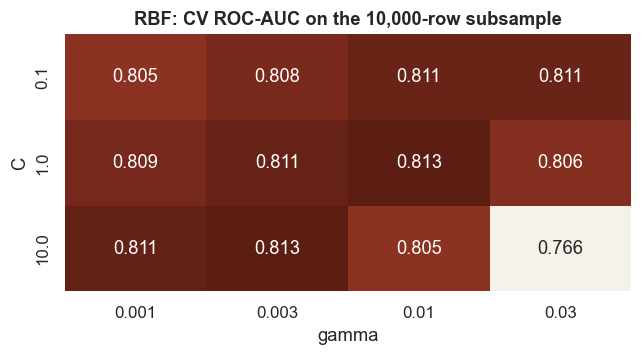

RBF best          : {'clf__C': 1, 'clf__gamma': 0.01}  CV ROC-AUC 0.8131   (grid search 30s)
linear SVC best   : {'clf__C': 0.1}  CV ROC-AUC 0.8085


In [11]:
N_SUB = 10_000
X_sub, _, y_sub, _ = train_test_split(X_train, y_train, train_size=N_SUB,
                                      random_state=SEED, stratify=y_train)
CV3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

def svc_pipe(**kw):
    return Pipeline([("scale", StandardScaler()),
                     ("clf", SVC(class_weight="balanced", **kw))])

rbf_grid = GridSearchCV(svc_pipe(kernel="rbf"),
                        param_grid={"clf__C": [0.1, 1, 10],
                                    "clf__gamma": [0.001, 0.003, 0.01, 0.03]},
                        scoring="roc_auc", cv=CV3, n_jobs=-1)
t0 = time.perf_counter(); rbf_grid.fit(X_sub, y_sub); rbf_search_time = time.perf_counter() - t0

lin_sub_grid = GridSearchCV(svc_pipe(kernel="linear"),
                            param_grid={"clf__C": [0.01, 0.1, 1]},
                            scoring="roc_auc", cv=CV3, n_jobs=-1)
lin_sub_grid.fit(X_sub, y_sub)

rbf_cv = (pd.DataFrame(rbf_grid.cv_results_)
          .pivot(index="param_clf__C", columns="param_clf__gamma", values="mean_test_score"))
fig, ax = plt.subplots(figsize=(6, 3.4))
sns.heatmap(rbf_cv, annot=True, fmt=".3f", cmap=SEQ, cbar=False, ax=ax)
ax.set_xlabel("gamma"); ax.set_ylabel("C")
ax.set_title("RBF: CV ROC-AUC on the 10,000-row subsample")
plt.tight_layout(); plt.show()

print(f"RBF best          : {rbf_grid.best_params_}  CV ROC-AUC {rbf_grid.best_score_:.4f}"
      f"   (grid search {rbf_search_time:.0f}s)")
print(f"linear SVC best   : {lin_sub_grid.best_params_}  CV ROC-AUC {lin_sub_grid.best_score_:.4f}")

In [12]:
rbf_best, rbf_fit_time = timed_fit(rbf_grid.best_estimator_, X_sub, y_sub)
lin_sub, lin_sub_fit_time = timed_fit(lin_sub_grid.best_estimator_, X_sub, y_sub)

t0 = time.perf_counter(); d_rbf = rbf_best.decision_function(X_test)
rbf_pred_time = time.perf_counter() - t0
d_lin_sub = lin_sub.decision_function(X_test)

evaluate("RBF SVM, 10k subsample", d_rbf, (d_rbf >= 0).astype(int), rbf_fit_time)
evaluate("Linear SVC, 10k subsample", d_lin_sub, (d_lin_sub >= 0).astype(int), lin_sub_fit_time)

print(f"RBF: {rbf_best[-1].n_support_.sum():,} support vectors; "
      f"scoring the {len(X_test):,}-row test set took {rbf_pred_time:.0f}s")
show_results(["Linear SVM (0 margin)", "Linear SVC, 10k subsample", "RBF SVM, 10k subsample"])

RBF: 5,914 support vectors; scoring the 50,736-row test set took 32s


,Accuracy,Recall,Precision,F1,ROC-AUC,Fit time (s)
Model,,,,,,
Linear SVM (0 margin),0.727,0.765,0.338,0.469,0.816,0.504
"Linear SVC, 10k subsample",0.711,0.782,0.326,0.461,0.814,4.012
"RBF SVM, 10k subsample",0.701,0.792,0.319,0.455,0.813,5.223


### Interpretation

Most settings score between 0.805 and 0.813, and the best one is `C = 1`,
`gamma = 0.01`. The worst is the most flexible setting we tried (`C = 10`,
`gamma = 0.03`, 0.766). A boundary that bends around single training points is
fitting noise, so it does worse on the held-out fold.

On the test set the RBF model does not beat the linear models. Its ROC-AUC is
0.813, compared with 0.814 for the linear SVC on the same 10,000 rows and 0.816
for the linear SVM on all 202,944 rows. So a curved boundary doesn't find
anything a straight one misses, which is what we expected from Lab 1. It also
takes about half a minute to score the test set (the linear models take a
fraction of a second), and it couldn't be trained on the full data.

Our recommendation is to use the linear kernel for this dataset. It trains on all
the data in under a second, matches logistic regression, and does at least as
well as an RBF kernel that can only be trained on 5% of the data.

# 5. Comparing the Models

In [13]:
headline = ["Predict nobody has diabetes", "Logistic, tuned (0.50)",
            "Logistic, tuned (F1 threshold)", "Linear SVM (0 margin)",
            "Linear SVM (F1 threshold)",
            "Linear SVC, 10k subsample", "RBF SVM, 10k subsample"]
display(show_results(headline))

,Accuracy,Recall,Precision,F1,ROC-AUC,Fit time (s)
Model,,,,,,
Predict nobody has diabetes,0.842,0.000,0.000,0.000,0.500,NaN
"Logistic, tuned (0.50)",0.728,0.762,0.339,0.469,0.816,0.604
"Logistic, tuned (F1 threshold)",0.779,0.653,0.382,0.482,0.816,0.604
Linear SVM (0 margin),0.727,0.765,0.338,0.469,0.816,0.504
Linear SVM (F1 threshold),0.783,0.636,0.385,0.480,0.816,0.504
"Linear SVC, 10k subsample",0.711,0.782,0.326,0.461,0.814,4.012
"RBF SVM, 10k subsample",0.701,0.792,0.319,0.455,0.813,5.223


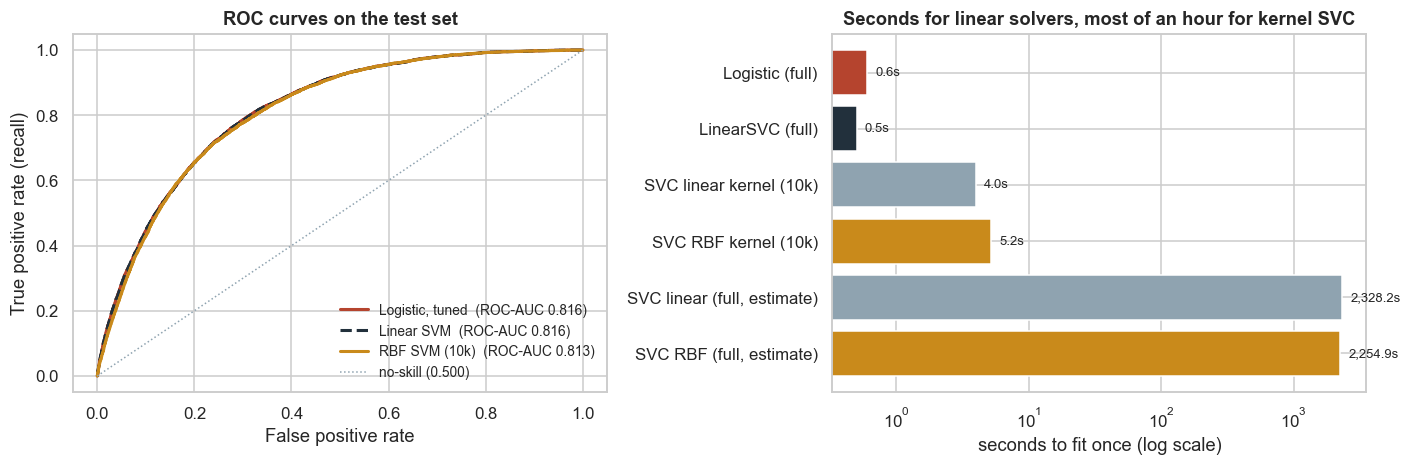

Share of test rows given the same label at F1 thresholds : 99.0%


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

curves = [("Logistic, tuned", p_lr, PALETTE["pos"], "-"),
          ("Linear SVM", d_svm, PALETTE["ink"], "--"),
          ("RBF SVM (10k)", d_rbf, PALETTE["accent"], "-")]
for name, s, color, ls in curves:
    fpr, tpr, _ = roc_curve(y_test, s)
    axes[0].plot(fpr, tpr, ls, color=color, lw=2,
                 label=f"{name}  (ROC-AUC {roc_auc_score(y_test, s):.3f})")
axes[0].plot([0, 1], [0, 1], color=PALETTE["neg"], lw=1, ls=":", label="no-skill (0.500)")
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate (recall)")
axes[0].set_title("ROC curves on the test set")
axes[0].legend(frameon=False, fontsize=9, loc="lower right")

fit_times = pd.Series({
    "Logistic (full)":        lr_fit_time,
    "LinearSVC (full)":       svm_fit_time,
    "SVC linear kernel (10k)":  lin_sub_fit_time,
    "SVC RBF kernel (10k)":     rbf_fit_time,
    "SVC linear (full, estimate)": extrap["linear"],
    "SVC RBF (full, estimate)":  extrap["rbf"],
})
colors = [PALETTE["pos"], PALETTE["ink"], PALETTE["neg"],
          PALETTE["accent"], PALETTE["neg"], PALETTE["accent"]]
axes[1].barh(fit_times.index[::-1], fit_times.values[::-1], color=colors[::-1])
axes[1].set_xscale("log")
axes[1].set_xlabel("seconds to fit once (log scale)")
axes[1].set_title("Seconds for linear solvers, most of an hour for kernel SVC")
for i, v in enumerate(fit_times.values[::-1]):
    axes[1].text(v * 1.15, i, f"{v:,.1f}s", va="center", fontsize=8.6)

plt.tight_layout(); plt.show()

same = ((p_lr >= lr_thr) == (d_svm >= svm_thr)).mean()
print(f"Share of test rows given the same label at F1 thresholds : {100*same:.1f}%")

### Does one model offer superior prediction performance?

No. Logistic regression and the linear SVM perform the same in practice. At
their F1 thresholds they give 99.0% of the test respondents the same label, and
their ROC curves are right on top of each other (left panel). This makes sense,
because both models draw a straight boundary using a weighted sum of the same
features, and here they end up with nearly the same weights (Section 6.1).

The RBF kernel isn't better either (ROC-AUC 0.813 vs 0.816), even though it can
draw a curved boundary.

### Does one offer superior training time or efficiency?

On the full data, logistic regression and `LinearSVC` both train in under a
second, so neither one is really faster. The big difference is the kernel
solver. `SVC` takes several seconds for 10,000 rows and would take most of an
hour for the full training set, and its prediction time grows with the number of
support vectors. The linear methods are thousands of times faster (right panel,
log scale).

### Advantages of each model for this task

| | Logistic regression | Linear SVM | RBF SVM |
|---|---|---|---|
| Accuracy (ROC-AUC) | 0.816 | 0.816 | 0.813 (10k rows) |
| Output | A probability, which can be used directly as a risk score | A decision value with no probability scale | Same as linear SVM |
| Interpretability | Weights can be turned into odds ratios (Section 6) | Weights rank the features the same way, but can't be read as odds | No weight per feature |
| Training on 200k rows | < 1 s | < 1 s (`LinearSVC`) | Most of an hour per fit (estimated) |
| Outliers | Every point affects the fit | Only points near the margin matter, so far-away points are ignored | Same as linear SVM |
| Non-linear patterns | Only if we add features by hand | Only if we add features by hand | Learned automatically |

For a screening tool on this data, we think logistic regression is the better
choice. It ties the SVM on accuracy and speed, and it gives a probability that is
easy to explain to a doctor ("your odds are 1.7 times higher for each step worse
in general health"). The SVM's main advantage, ignoring points far from the
boundary, doesn't help here because most points are close to the boundary
(Section 7).

# 6. Interpreting the Logistic Regression Weights

The table has two columns:

* weight: the logistic regression coefficient. All features were standardized
  before fitting, so the weights are on the same scale and can be compared. A
  bigger weight (ignoring the sign) means the feature matters more to the model.
  A positive weight raises the predicted risk and a negative weight lowers it.
* odds ratio per unit: how much the odds of a diabetes diagnosis get multiplied
  by for one step of the feature in its own units (one BMI point, one age band,
  or yes vs no), *keeping the other 17 features the same*. Above 1 means higher
  odds and below 1 means lower odds.

In [15]:
scaler = lr_best.named_steps["scale"]
coef   = pd.Series(lr_best.named_steps["clf"].coef_[0], index=FEATURES)

weights = pd.DataFrame({
    "weight":               coef,
    "odds ratio per unit":  np.exp(coef / scaler.scale_),
}).reindex(coef.abs().sort_values(ascending=False).index)

display(weights.round(3))
print(f"features with |weight| > 0.10 : {(coef.abs() > 0.10).sum()} of {len(coef)}")

,weight,odds ratio per unit
GenHlth,0.562,1.694
BMI,0.470,1.074
Age,0.443,1.156
HighBP,0.341,1.993
HighChol,0.292,1.807
HvyAlcoholConsump,-0.139,0.547
Income,-0.122,0.943
Sex,0.115,1.261
HeartDiseaseorAttack,0.070,1.271
Education,-0.045,0.956


features with |weight| > 0.10 : 8 of 18


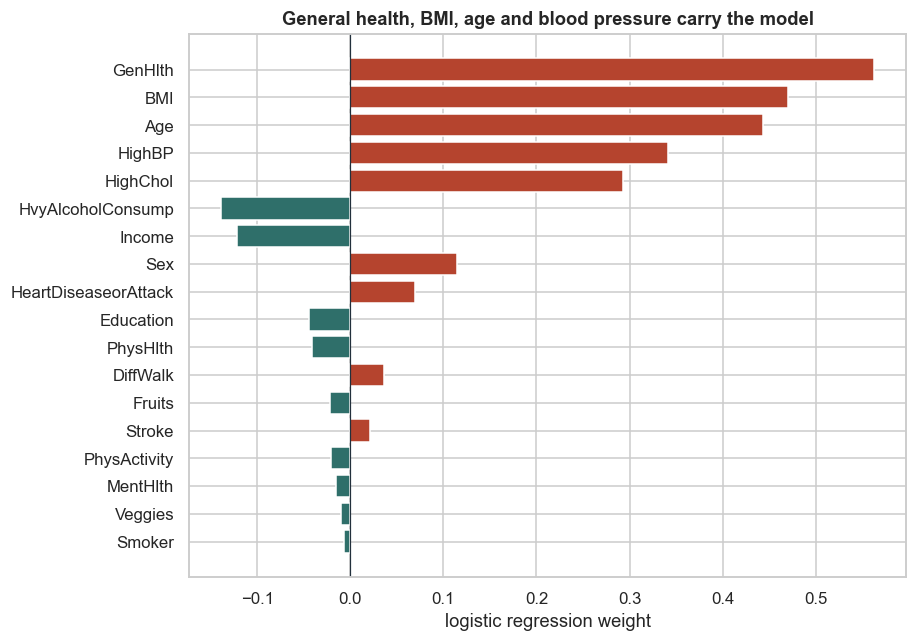

In [16]:
w_sorted = coef.reindex(coef.abs().sort_values().index)

fig, ax = plt.subplots(figsize=(8.5, 6))
ax.barh(w_sorted.index, w_sorted.values,
        color=[PALETTE["pos"] if v > 0 else PALETTE["prot"] for v in w_sorted.values])
ax.axvline(0, color=PALETTE["ink"], lw=0.8)
ax.set_xlabel("logistic regression weight")
ax.set_title("General health, BMI, age and blood pressure carry the model")
plt.tight_layout(); plt.show()

### Interpretation

Five features have much bigger weights than the rest: general health, BMI, age,
high blood pressure and high cholesterol, with weights between 0.29 and 0.56. The
next biggest is heavy alcohol use at 0.14. All five were in the top six of Lab 1's
Cramér's V table, and three of them (blood pressure, cholesterol and BMI) are the
"metabolic cluster" from Lab 1's Key Finding #2.

| Feature | Effect on the odds of diagnosis |
|---|---|
| `HighBP` | 1.99x for someone told they have high blood pressure |
| `HighChol` | 1.81x for high cholesterol |
| `GenHlth` | 1.69x for each step worse on the 5-point self-rated health scale |
| `Age` | 1.16x per five-year age band, so about 2x over 25 years |
| `BMI` | 1.07x per BMI point, so about 2x for 10 points |

Why these features matter most: they are the most directly related to the
biology of diabetes. High blood pressure, high cholesterol and excess weight are
all part of metabolic syndrome, along with type 2 diabetes. They have shared
causes (like insulin resistance), and doctors often check blood sugar when they
find one of them, which also makes a *diagnosis* more likely. Age is the biggest
risk factor for type 2 diabetes, and older people have also had more years to get
tested. General health has the largest weight, but Lab 1 pointed out that it is
partly a result of diabetes: people with diabetes rate their health lower
*because* they have it. So it helps the model predict, but it isn't a cause.

Some weights were surprising:

* Heavy alcohol use lowers the odds (odds ratio 0.55). This is very unlikely to
  be a real benefit. People diagnosed with diabetes are told to cut back on
  alcohol, and people who are already sick tend to drink less. So the diagnosis
  probably causes less drinking, not the other way around (reverse causation).
  Lab 1 found the same pattern for underweight BMI.
* Physical health days has a small negative weight, even though diagnosed
  diabetics report more than twice as many bad physical-health days (7.96 vs 3.50
  in the sample, Section 7). `GenHlth` and `DiffWalk` already carry most of that
  information, so what's left for `PhysHlth` is a small adjustment, and its sign
  doesn't mean much. This is the multicollinearity Lab 1's VIF analysis found.
  A weight shows the effect of a feature *given the other features*, not its
  overall relationship with diabetes.
* Heart disease has a small weight (0.07, odds ratio 1.27) even though Lab 1
  found a strong association. Heart disease has the same causes as high blood
  pressure, high cholesterol and age, so those features take most of its weight.
* Income is still negative (0.94x per income band) after accounting for health.
  People with lower income are more likely to be diagnosed even when they have
  the same BMI, blood pressure and self-rated health. This matches the income
  pattern in Lab 1. Since lower-income people have less access to testing, the
  real difference might be even bigger.
* Being male raises the odds by 1.26x, which fits with men developing type 2
  diabetes at a lower BMI than women. Sex was 19th of 20 in Lab 1's Cramér's V
  table but is 8th here. On its own it doesn't separate the classes much, but
  for people with the same BMI and age the difference shows up. `DiffWalk` is the
  opposite: 4th in Cramér's V but 12th here, because difficulty walking mostly
  reflects poor health and high BMI, which are already in the model. So how
  strongly a feature is related to diabetes on its own is not the same as how
  much it adds to the model.
* Smoking and eating vegetables don't matter much. Their weights are about 0.01,
  the smallest in the model. These are yes/no questions about the past 30 days,
  which are probably too rough to add anything once BMI and age are known.

## 6.1 Do the SVM Weights Agree?

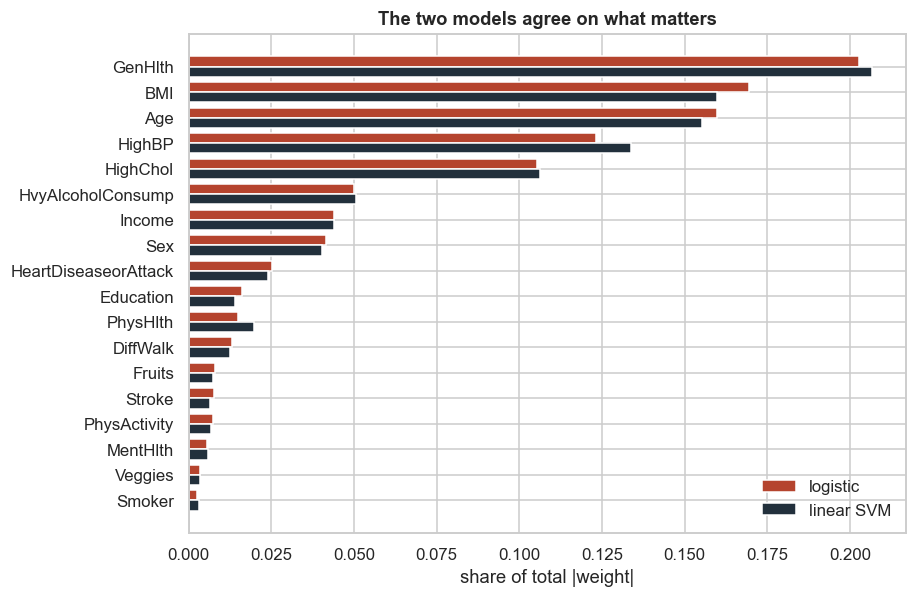

same sign on every feature : True
top five, logistic : ['GenHlth', 'BMI', 'Age', 'HighBP', 'HighChol']
top five, SVM      : ['GenHlth', 'BMI', 'Age', 'HighBP', 'HighChol']


In [17]:
svm_w = pd.Series(svm_best.named_steps["clf"].coef_[0], index=FEATURES)

# The two models use different losses, so the weights live on different scales;
# comparing each as a share of its own total magnitude puts them side by side
share = pd.DataFrame({"logistic": coef.abs() / coef.abs().sum(),
                      "linear SVM": svm_w.abs() / svm_w.abs().sum()})
share = share.sort_values("logistic")

fig, ax = plt.subplots(figsize=(8.5, 5.6))
ypos = np.arange(len(share))
ax.barh(ypos + 0.2, share["logistic"], 0.4, color=PALETTE["pos"], label="logistic")
ax.barh(ypos - 0.2, share["linear SVM"], 0.4, color=PALETTE["ink"], label="linear SVM")
ax.set_yticks(ypos); ax.set_yticklabels(share.index)
ax.set_xlabel("share of total |weight|")
ax.set_title("The two models agree on what matters")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

print(f"same sign on every feature : {bool((np.sign(coef) == np.sign(svm_w)).all())}")
print(f"top five, logistic : {coef.abs().nlargest(5).index.tolist()}")
print(f"top five, SVM      : {svm_w.abs().nlargest(5).index.tolist()}")

### Interpretation

The linear SVM's weights have the same sign as the logistic regression weights
for all 18 features, and both models have the same top five features. So the
feature importance results come from the data, not from the choice of logistic
regression. Any linear model would find the same five main features.

# 7. Looking at the Support Vectors

Support vectors are the training points that define the SVM's boundary. They
are the points on the margin, inside the margin, or on the wrong side of the
boundary. All other points could be removed and the model would stay the same.

`LinearSVC` doesn't save its support vectors, so in this section we use the
linear-kernel `SVC` trained on the 10,000-row sample from Section 4.3. Its test
performance is close to the full-data linear SVM (ROC-AUC 0.814 vs 0.816), so its
support vectors should be representative.

In [18]:
svc = lin_sub.named_steps["clf"]
sv_idx = X_sub.index[svc.support_]

sv_counts = pd.DataFrame({
    "rows in subsample": y_sub.value_counts().sort_index(),
    "support vectors":   y_sub.loc[sv_idx].value_counts().sort_index(),
}).rename(index={0: "no diabetes", 1: "diabetes"})
sv_counts["share that are SVs %"] = 100 * sv_counts["support vectors"] / sv_counts["rows in subsample"]
display(sv_counts.round(1))

print(f"support vectors : {len(sv_idx):,} of {len(X_sub):,} ({100*len(sv_idx)/len(X_sub):.0f}%)")

,rows in subsample,support vectors,share that are SVs %
Diabetes_binary,,,
no diabetes,8424,5086,60.400
diabetes,1576,958,60.800


support vectors : 6,044 of 10,000 (60%)


no diabetes                diabetes               
                             all    SVs non-SVs      all    SVs non-SVs
GenHlth                    2.380  2.810   1.710    3.270  2.820   3.980
BMI                       27.770 29.330  25.390   31.360 29.340  34.490
HighBP                     0.370  0.590   0.030    0.740  0.590   0.960
Age                        7.730  8.940   5.900    9.270  8.950   9.780
HighChol                   0.370  0.540   0.130    0.660  0.540   0.840
HeartDiseaseorAttack       0.080  0.130   0.010    0.210  0.130   0.340
PhysHlth                   3.500  4.970   1.270    7.960  5.010  12.530
Income                     6.180  5.740   6.840    5.160  5.730   4.270
DiffWalk                   0.130  0.210   0.010    0.370  0.210   0.620
HvyAlcoholConsump          0.060  0.040   0.090    0.020  0.040   0.000

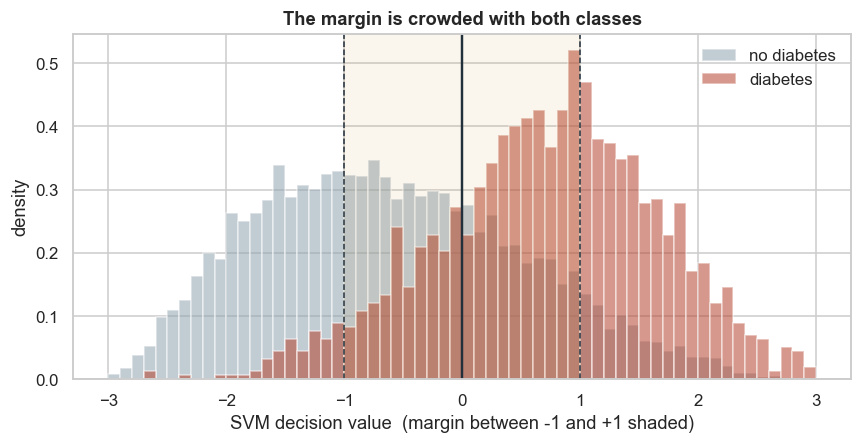

In [19]:
key = ["GenHlth", "BMI", "HighBP", "Age", "HighChol", "HeartDiseaseorAttack",
       "PhysHlth", "Income", "DiffWalk", "HvyAlcoholConsump"]

# Average of each feature for all rows, support vectors and the rest, by class
is_sv = X_sub.index.isin(sv_idx)
profile = {}
for label, cls in [("no diabetes", 0), ("diabetes", 1)]:
    in_cls = (y_sub == cls).values
    profile[(label, "all")]      = X_sub.loc[in_cls, key].mean()
    profile[(label, "SVs")]      = X_sub.loc[in_cls & is_sv, key].mean()
    profile[(label, "non-SVs")]  = X_sub.loc[in_cls & ~is_sv, key].mean()
profile = pd.DataFrame(profile)
display(profile.round(2))

# Where the training rows fall relative to the margin
scores_sub = lin_sub.decision_function(X_sub)
fig, ax = plt.subplots(figsize=(8, 4.2))
bins = np.linspace(-3, 3, 61)
for cls, color, name in [(0, PALETTE["neg"], "no diabetes"), (1, PALETTE["pos"], "diabetes")]:
    ax.hist(scores_sub[(y_sub == cls).values], bins=bins, color=color,
            alpha=0.55, density=True, label=name)
for x in (-1, 0, 1):
    ax.axvline(x, color=PALETTE["ink"], lw=1 if x else 1.6, ls="--" if x else "-")
ax.axvspan(-1, 1, color=PALETTE["accent"], alpha=0.08)
ax.set_xlabel("SVM decision value  (margin between -1 and +1 shaded)")
ax.set_ylabel("density")
ax.set_title("The margin is crowded with both classes")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

### What the support vectors tell us

60% of the sample are support vectors, and the share is about the same in each
class. If the classes were clearly separated there would only be a few support
vectors. Here the SVM needs most of the training rows to place the boundary,
which shows that the two classes overlap a lot. Lab 1 found the same thing with
PCA: the diabetic group was shifted a little but mostly covered the same area as
the non-diabetic group.

Support vectors from the two classes look almost the same. In the profile table,
non-diabetic support vectors have an average general health of 2.81, BMI 29.3,
59% with high blood pressure and age band 8.9 (about 60). Diabetic support vectors
average 2.82, 29.3, 59% and 8.95. On paper they are the same kind of person:
middle-aged, overweight, in fair-to-good health, and about 60% with high blood
pressure. The non-diabetic support vectors are sicker than the average
non-diabetic (general health 2.81 vs 2.38, BMI 29.3 vs 27.8), and the diabetic
support vectors are healthier than the average diabetic (2.82 vs 3.27, BMI 29.3
vs 31.4). So from each class, the support vectors are the people who look most
like the other class.

The rows that are not support vectors are the easy cases. The non-diabetics the
model doesn't need are younger (age band 5.9, late 40s), leaner (BMI 25.4),
almost never have high blood pressure (3%) and rate their health as very good
(1.71). The diabetics it doesn't need are the opposite: BMI 34.5, 96% with high
blood pressure, fair-to-poor health (3.98) and 12.5 bad physical-health days a
month. The model separates these extremes easily, and most of its mistakes come
from the big group in the middle.

In practice, the support vectors are the people a screening program should care
about most: people whose answers look like those of diagnosed diabetics but who
haven't been diagnosed. Lab 1 suggested that some of the "negatives" in this data
are actually undiagnosed diabetics. The non-diabetic support vectors, who are
sicker than the rest of their class on every metabolic measure, are where we
would expect to find them. The model can't tell them apart from diagnosed cases
with these features, and that might be because some of them really do have
diabetes.

# 8. Conclusions

1. Logistic regression and the linear SVM performed the same. On the 50,736-row
   test set both got a ROC-AUC of 0.82 (guessing would be 0.50), and they gave
   99.0% of people the same label. With class weights, they find about three out
   of four diagnosed diabetics at 34% precision. At the F1 threshold they find
   about two out of three at 38% precision.

2. Tuning `C` changed almost nothing, and the threshold mattered more. With 203k
   rows and 18 features neither model overfits, so the regularization strength
   didn't matter across the whole range we tried. What changed the results was
   class weighting and the decision threshold, which control the tradeoff
   between recall and precision. Those are decisions about how costly each kind
   of error is, not about how good the model is.

3. The linear kernel is the right choice for this data. Kernel `SVC` time grows
   with the square of the rows, so at 203k rows each fit would take most of an
   hour. An RBF kernel trained on 10,000 rows did not beat the linear models
   (ROC-AUC 0.813 vs 0.816), and its most flexible settings did the worst.

4. Five features matter most: general health, BMI, age, high blood pressure and
   high cholesterol. The logistic regression weights and the linear SVM weights
   agree on this, and it matches our EDA from Lab 1. Heavy alcohol use and
   physical-health days look protective, but this comes from reverse causation
   and collinearity, not a real benefit.

5. The support vectors show how much the classes overlap. 60% of the training
   rows are support vectors, and the support vectors from both classes have
   almost the same average profile. The boundary is set by a large middle group
   of middle-aged, overweight people in fair health who could be in either class.
   Better tuning won't fix this. We would need better features, like a blood
   glucose or HbA1c test, instead of survey answers.

Limitations: the target is a self-reported diagnosis, so the models learn who
gets diagnosed, not who has diabetes. We treated ordinal features as linear. The
RBF comparison only used 5% of the training data. Also, the sample is much older
than the US adult population (Lab 1, Section 5), so these results describe BRFSS
respondents and not the general public.

# 9. Sources

scikit-learn developers. *scikit-learn User Guide and API Reference*, version 1.9. The following pages were used:

1. Setup (train/test split, scaling, pipelines)
   - `train_test_split`: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
   - `StandardScaler`: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
   - Pipelines: https://scikit-learn.org/stable/modules/compose.html#pipeline

2. Logistic regression, class weights, regularization and threshold
   - `LogisticRegression`: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
   - `DummyClassifier`: https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html
   - Cross-validation: https://scikit-learn.org/stable/modules/cross_validation.html
   - Grid search: https://scikit-learn.org/stable/modules/grid_search.html
   - Tuning the decision threshold: https://scikit-learn.org/stable/modules/classification_threshold.html

3. Support vector machines
   - SVM user guide: https://scikit-learn.org/stable/modules/svm.html
   - RBF SVM parameters: https://scikit-learn.org/stable/auto_examples/svm/plot_rbf_parameters.html
   - `LinearSVC`: https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html

4. Comparing the models
   - Logistic regression: https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
   - James, G., Witten, D., Hastie, T. and Tibshirani, R. *An Introduction to Statistical Learning*, Section 9.5, "Relationship to Logistic Regression".

5. Interpreting the weights
   - Common pitfalls in the interpretation of coefficients of linear models: https://scikit-learn.org/stable/auto_examples/inspection/plot_linear_model_coefficient_interpretation.html

6. Support vectors
   - SVM mathematical formulation: https://scikit-learn.org/stable/modules/svm.html#mathematical-formulation
   - SVM maximum margin separating hyperplane: https://scikit-learn.org/stable/auto_examples/svm/plot_separating_hyperplane.html